In [28]:
%load_ext autoreload
%autoreload 2

import uproot
import awkward as ak

import matplotlib.pylab as plt
import numpy as np

import time

from hist import Hist

import babar_analysis_tools as bat

from analysis_variables import *

import myPIDselector

import pandas as pd
import seaborn as sns

import joblib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Open the data file or files

In [33]:
#####################################################################
# Where are we running this?
#####################################################################
## Bellis computer
#topdir= "/home/bellis/babar_data/bnv_analysis_lam0lam0"
topdir= "/home/bellis/babar_data_local/bnv_analysis_lam0lam0"

## Somewhere else?
#topdir= "/Users/josieswann/BaBar_analyses/BNV_pLambda/"
#####################################################################


#####################################################################
# Get the BNV data
#####################################################################
data, data_collision = bat.load_datasets(topdir=topdir, subset='all')


Opening /home/bellis/babar_data_local/bnv_analysis_lam0lam0/Background_and_signal_SP_modes_All_runs.parquet...
Took 0.561 seconds

Opening /home/bellis/babar_data_local/bnv_analysis_lam0lam0/Data_All_runs_BLINDED.parquet...
Took 0.179 seconds



In [34]:
# Run over collision data
#data = data_collision
#IS_MC=False

## Add an entry with the tag-side B variable(s)

In [41]:
bat.fill_new_entry_with_tag_side_B(data, final_state='lam0lam0')
bat.fill_new_entry_with_tag_side_B(data_collision, final_state='lam0lam0')

#data['BtagSideMes']
#data_collision['BtagSideMes']

# Get information about cross sections and numbers of events

In [42]:
### information about cross section --> what we'll use to calculate scaling values for histograms 

dataset_information = pd.read_csv("dataset_statistics.csv")
cs_data= pd.read_csv("SP_cross_sections_and_labels.csv")

no_notes= cs_data.drop(["Uncertainty","Note: cross sections found at https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Physics/Cross_sections,_luminosities,_and_other_vital_stats"], axis= 1)
no_notes

,SP Mode,Human-readable label,LaTeX output,Cross section [nb]
0,1235,B+B- pairs,$B^+ B^-$,0.525
1,1237,B0 B0bar pairs,$B^0\overline{B^0}$,0.525
2,1005,ccbar,$c\bar{c}$,1.300
3,998,uubar/ddbar/ssbar,"$u\bar{u}, d\bar{d}, c\bar{c}$",2.090
4,2400,bhabha- e+e- to e+e-,$e^+e^-$,40.000
5,3429,tau+tau-,$\tau^+\tau^-$,0.919
6,3981,mu+mu- gamma,$\mu^+\mu^-\gamma$,1.147


In [43]:
dataset_information

,Data or MC,SP mode,Run,Skim,# of events (Data or MC),# of events (Data or MC) NOT SURE WHICH NUMBER TO USE,Luminosity (Data only) 1/pb,# of collections/files (Data or MC),Missing collections?
0,Data,-1,1,NaN,292554209,928849927,20782.9,3306,1
1,Data,-1,2,NaN,958854016,2255075947,61643.1,5214,0
2,Data,-1,3,NaN,501277316,1160966741,32530.3,3678,0
3,Data,-1,4,NaN,1590601212,3748112198,101454.8,6667,10
4,Data,-1,5,NaN,2104338820,4982538289,134908.1,8057,0
...,...,...,...,...,...,...,...,...,...
103,MC,991,2,LambdaVeryVeryLoose,0,0,0.0,0,0
104,MC,991,3,LambdaVeryVeryLoose,0,0,0.0,0,0
105,MC,991,4,LambdaVeryVeryLoose,0,0,0.0,0,0
106,MC,991,5,LambdaVeryVeryLoose,0,0,0.0,0,0


# Make a few test histograms 

In [44]:
sp = data['spmode']

np.unique(sp.to_list())

array(['-999', '1005', '1235', '1237', '3429', '998'], dtype='<U4')

In [45]:
region_definitions

{'Area': ['Fitting area', 'Signal area'],
 'signal MES': [5.27, 5.3],
 'fitting MES': [5.2, 5.3],
 'signal DeltaE': [-0.07, 0.07],
 'fitting DeltaE': [-0.2, 0.2],
 'sideband 1 DeltaE': [0.07, 0.14],
 'sideband 2 DeltaE': [-0.14, -0.07],
 'sideband MES': [5.27, 5.3],
 'inference': [[5.27, 5.3, -0.07, 0.07],
  [5.27, 5.3, -0.2, -0.07],
  [5.27, 5.3, 0.07, 0.2],
  [5.25, 5.27, -0.2, 0.0],
  [5.25, 5.27, 0.0, 0.2],
  [5.23, 5.25, -0.2, 0.0],
  [5.23, 5.25, 0.0, 0.2],
  [5.2, 5.23, -0.2, 0.0],
  [5.2, 5.23, 0.0, 0.2]],
 'Lambda0 mass': [1.112683, 1.1186829999999999],
 'Lambda0 flightlen': 25.0}

In [46]:
#hist_defs

## Create standard empty histograms

In [10]:
# Make our histograms
all_hists = bat.create_empty_histograms(hist_defs)

bkg_spmodes = ['998', '1005', '1235', '1237', '3981']
sig_spmodes = ['-999']

spmodes = bkg_spmodes + sig_spmodes

weights = {}
for sp in spmodes:
    weights[sp] = bat.scaling_value(int(sp), dataset_information=dataset_information, cs_data=cs_data, plot=False, verbose=False)
    #weights[sp] = 1

### bat.scaling_value is in Babar_analysis_tools.py 

# Scale the signal higher
weights['-999'] = 1000
weights['0'] = 1

print(weights)
print()
print(spmodes)

{'998': 0.2506879075487834, '1005': 0.49619965664110677, '1235': 0.3191592629119508, '1237': 0.31492522877218293, '3981': 0.7950555869080849, '-999': 1000, '0': 1}

['998', '1005', '1235', '1237', '3981', '-999']


Signal region
-0.07 0.07
5.27 5.30  -0.07   0.07    446
signal: 446   fit: 7656  s1: 191  s2: 0  sum(s1,s2): 191


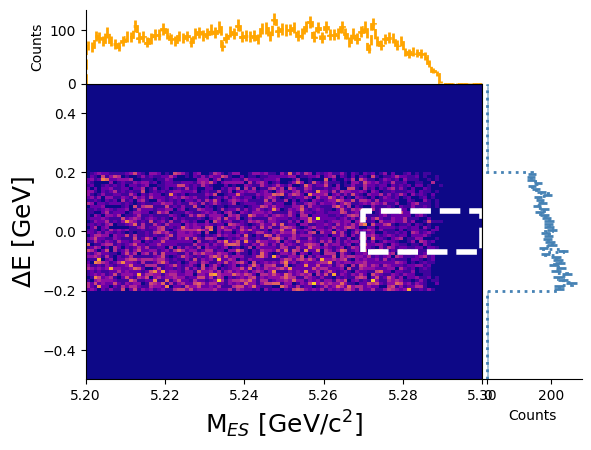

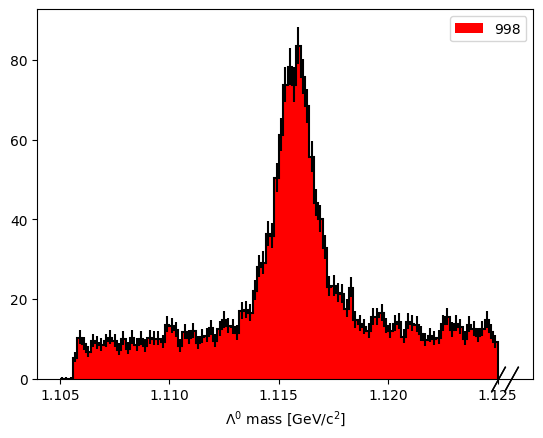

In [11]:
# Pull out some SP mode
#spmode = '1005'
spmode='998'
#spmode='991'
#spmode='-999'
#spmode='0'
mask_sp = data['spmode'] == spmode

# Collision data
#mask_sp = data['spmode']=='0'

# Make a subset
data_sp = data[mask_sp]

# For data we need to account for blinding
#if IS_MC is False:
#    nB = data_sp['nB']
#    Bp3 = data_sp['Bp3']
#    nBp3 = ak.num(Bp3)
#    
#    mask_to_account_for_blinding = nB == nBp3
#    print(len(nB[mask_to_account_for_blinding]), len(nB[~mask_to_account_for_blinding]))
#    
#    data_sp = data_sp[mask_to_account_for_blinding]

# Use only the data in the fitting region
fit_mask = bat.get_fit_mask(data_sp, region_definitions)

# Make the plot
mes =    ak.flatten(data_sp['BpostFitMes'][fit_mask])
DeltaE = ak.flatten(data_sp['BpostFitDeltaE'][fit_mask])

bat.plot_mes_vs_DeltaE(mes, DeltaE, region_definitions=region_definitions, draw_signal_region=True)

#print(len(mes),len(DeltaE))

## Other HISTOGRAMS 
all_hists = bat.create_empty_histograms(hist_defs)
x = ak.flatten(data_sp['Lambda0_unc_Mass'][fit_mask])
weight = weights[spmode]
all_hists['Lambda0_unc_Mass'].fill(var=x, SP= spmode, cuts= f"{0}", weight= weight)

plt.figure()
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="fill", color='red', label= spmode)
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="step", color='black')
plt.legend();

In [12]:
#mes

# Get the event-based cuts



''

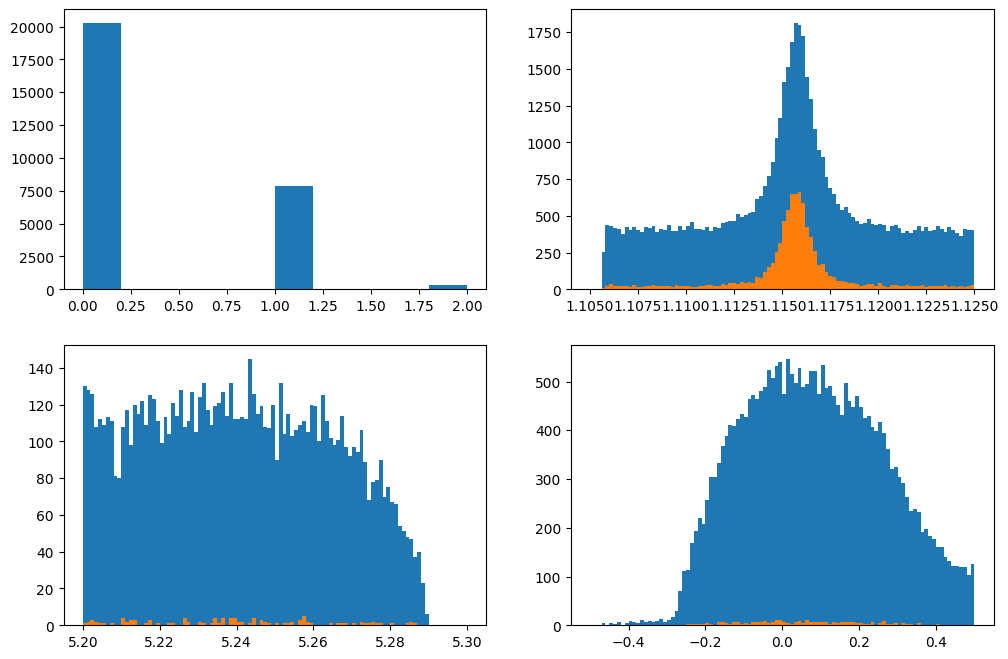

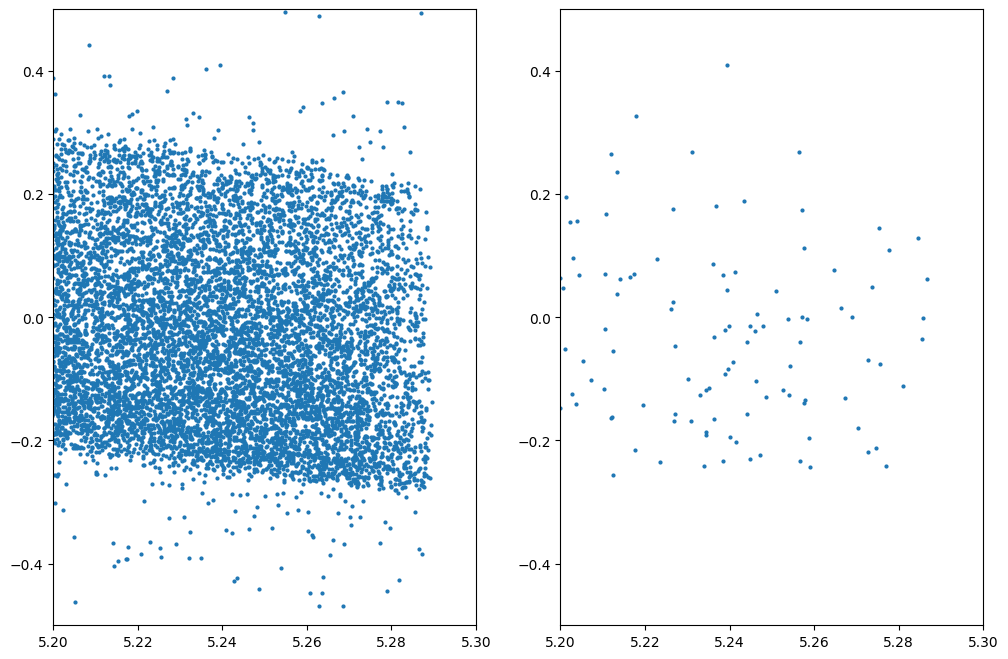

In [92]:
# Test out the lambda0 cut
#spmode='998'
spmode='1005'
#spmode='991'
#spmode='-999'
#spmode='0'
mask_sp = (data['spmode'] == spmode)

flightlenvar = 'Lambda0postFitFlightSignificance'

cutvariable = data[flightlenvar][mask_sp]

mask_fl = cutvariable>134.0 #region_definitions['Lambda0 flightlen']

# Cut on the mass 
lo = region_definitions['Lambda0 mass'][0]
hi = region_definitions['Lambda0 mass'][1]

m = data['Lambda0_unc_Mass'][mask_sp]
mes = data['BpostFitMes'][mask_sp]
de =  data['BpostFitDeltaE'][mask_sp]

#mask_lambda0 = (m>lo) & (m<hi) & mask_fl
mask_lambda0 = mask_fl

mask_lambda0_all = ak.all(mask_fl, axis=-1)


# We also only want to keep events with one B candidate and one Lambda0 candidate, 
# so let's do that here
nlambda0 = ak.num(m[mask_lambda0])
mB = data['BpostFitMes']
nB = ak.num(mB)
#print(nlambda0)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.hist(nlambda0)

plt.subplot(2,2,2)
plt.hist(ak.flatten(m),bins=100, range=(1.105, 1.125));
plt.hist(ak.flatten(m[mask_lambda0]),bins=100, range=(1.105, 1.125));

plt.subplot(2,2,3)
plt.hist(ak.flatten(mes),bins=100, range=(5.2,5.3));
plt.hist(ak.flatten(mes[mask_lambda0_all]),bins=100, range=(5.2, 5.3));

plt.subplot(2,2,4)
plt.hist(ak.flatten(de),bins=100, range=(-.5,.5));
plt.hist(ak.flatten(de[mask_lambda0_all]),bins=100, range=(-.5, .5));

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.plot(ak.flatten(mes), ak.flatten(de), '.', markersize=4);
plt.xlim(5.2, 5.3)
plt.ylim(-0.5,0.5)

plt.subplot(1,2,2)
plt.plot(ak.flatten(mes[mask_lambda0_all]), ak.flatten(de[mask_lambda0_all]), '.', markersize=4);
plt.xlim(5.2, 5.3)
plt.ylim(-0.5,0.5)

;


#mask_event_nlambda0_and_nB = (nlambda0==1) & (nB==1)


In [ ]:
###################################
# SP
###################################

#splist= np.unique(sp.to_list())
#print(splist)

dcuts= bat.get_final_masks(data, region_definitions= region_definitions)

print([dcuts.keys()])
print()

for key in dcuts.keys():
    print(f'{key:3d} {dcuts[key]["name"]}')


###################################
# Collision
###################################

dcuts_col= bat.get_final_masks(data_collision, region_definitions= region_definitions)


#bkg_spmodes= ["998","1005","3981","1235","1237"]
#sig_spmodes= ["-999"]

#spmodes= bkg_spmodes+sig_spmodes
#
#weights= {}
#for sp in spmodes: 
#    weights[sp]= bat.scaling_value(int(sp),dataset_information=dataset_information, cs_data= cs_data, plot= False, verbose= False)
#    #weights[sp]=1

#weights["-999"]= 1000 #scales signal higher 
#weights["0"]= 1 #idk what this is for;;; ASK

#print(weights)

In [ ]:
# Need to get the original duplicates mask for any other cuts we might generate outside the function
#dcuts = bat.get_final_masks(data, region_definitions=region_definitions)

#print([dcuts.keys()])
#print()

#for key in dcuts.keys():
#    print(f'{key:3d} {dcuts[key]["name"]}')

In [ ]:
#dcuts[4]

In [ ]:
c = dcuts[4]['event']

print(len(c), len(c[c]))

In [ ]:
################################################################################
# Make the masks
#mask_event = dcuts[3]['event']
mask_event = dcuts[4]['event']
#mask_event = dcuts[1]['event']
#mask_event = dcuts[-1]['event']
#mask_event = dcuts[2]['event'] & dcuts[3]['event'] & dcuts[4]['event']

mask_event = (dcuts[1]['event']) & (dcuts[2]['event']) & (dcuts[3]['event']) & (dcuts[4]['event'])


spmode = '998'
#spmode = '1005'
#spmode = '-999'
#spmode = '1235'
#spmode = '0'

mask_sp = data['spmode']==spmode

mask = mask_sp & mask_event
################################################################################

# Make the plot
mes =    ak.flatten(data[mask]['BpostFitMes'])
DeltaE = ak.flatten(data[mask]['BpostFitDeltaE'])

bat.plot_mes_vs_DeltaE(mes, DeltaE, region_definitions=region_definitions, draw_signal_region=True, zoom=True, bins=25)

#print(len(mes),len(DeltaE))

## Other HISTOGRAMS 
all_hists = bat.create_empty_histograms(hist_defs)
x = ak.flatten(data[mask]['Lambda0_unc_Mass'])
weight = 1.0#weights[spmode]
all_hists['Lambda0_unc_Mass'].fill(var=x, SP= spmode, cuts= f"{0}", weight= weight)

plt.figure()
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="fill", color='red', label= spmode)
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="step", color='black')
plt.legend();

## Using the dataframes

In [ ]:
'''
# BNC
infilename = 'DATAFRAME_SP_MODEL_MLPClassifier_CUTS_1_2_3_nsig_20000_nbkg_20000_BNC.pkl'
df_sp = pd.read_parquet(infilename)

infilename = 'DATAFRAME_COL_MODEL_MLPClassifier_CUTS_1_2_3_nsig_20000_nbkg_20000_BNC.pkl'
df_col = pd.read_parquet(infilename)

infilename = 'MODEL_MLPClassifier_CUTS_1_2_3_nsig_20000_nbkg_20000_BNC.pkl'
workspace = joblib.load(infilename)
'''


# BNV
infilename = 'DATAFRAME_SP_MODEL_MLPClassifier_CUTS_1_2_3_nsig_20000_nbkg_20000.pkl'
df_sp = pd.read_parquet(infilename)

infilename = 'DATAFRAME_COL_MODEL_MLPClassifier_CUTS_1_2_3_nsig_20000_nbkg_20000.pkl'
df_col = pd.read_parquet(infilename)

infilename = 'MODEL_MLPClassifier_CUTS_1_2_3_nsig_20000_nbkg_20000.pkl'
workspace = joblib.load(infilename)

In [ ]:
df_col.columns

In [ ]:
probacut = 0.83
plt.figure(figsize=(8,8))

for i in range(0,3):

    idx = None
    spmode = None
    df_tmp = None
    
    if i==0:
        idx = workspace['idx_bkg_not_train']
        spmode = '998'
        df_tmp = df_sp.loc[idx]

    elif i==1:
        idx = workspace['idx_sig_not_train']
        spmode = '-999'
        df_tmp = df_sp.loc[idx]
    
    elif i==2:
        spmode = '0'
        df_tmp = df_col
    
    spmask = (df_tmp['spmode']==spmode)

    # BNC
    mask =   (df_tmp['cut_2']==True) & (df_tmp['cut_3']==True)  & (df_tmp['cut_4']==True)

    mask = mask & (df_tmp['proba'] > probacut)
    
    mask = mask & (df_tmp['BpostFitDeltaE']<0.05) & (df_tmp['BpostFitDeltaE']>-0.05)
    
    #var = 'proba'
    var = 'BpostFitMes'

    plt.subplot(3,1,i+1)
    df_tmp[spmask & mask][var].hist(bins=25, range=(5.2,5.3))#, range=(0,0.99))


# Write out the values

## parquet

In [ ]:
################################################################################
# Make the masks
#mask_event = dcuts[3]['event']
#mask_event = dcuts[4]['event']
mask_event = dcuts[1]['event']
#mask_event = dcuts[-1]['event']
#mask_event = dcuts[2]['event'] & dcuts[3]['event'] & dcuts[4]['event']

#spmode = '998'
#spmode = '1005'
spmode = '-999'
#spmode = '1235'

mask_sp = data['spmode']==spmode

mask = mask_sp & mask_event
################################################################################

# Make the plot
mes =    ak.flatten(data[mask]['BpostFitMes'])
DeltaE = ak.flatten(data[mask]['BpostFitDeltaE'])
out_array = ak.Array({'mes': mes, 'DeltaE': DeltaE})

output_filename = f'mes_deltae_{spmode}_AFTER_FINAL_CUTS.parquet'
ak.to_parquet(out_array, f'{output_filename}.parquet')


In [ ]:
print(f"Opening {output_filename}.parquet")

filename = f'{output_filename}.parquet'
#filename = f'bnv_plambda/Background_SP_modes_Only_Run_1.parquet'

start = time.time()

data_test = ak.from_parquet(filename)

print(f"Took {time.time() - start} s")

In [ ]:
data_test

In [ ]:
data_test['mes']

## dataframe

In [ ]:
################################################################################
# Make the masks
#mask_event = dcuts[3]['event']
#mask_event = dcuts[4]['event']
mask_event = dcuts[1]['event']
#mask_event = dcuts[-1]['event']
#mask_event = dcuts[2]['event'] & dcuts[3]['event'] & dcuts[4]['event']

tag = "FINAL_CUTS"
tag = "EARLY_CUT"

mask = mask_event
################################################################################
subset = ['spmode', 'BpostFitMes', 'BpostFitDeltaE', 'Lambda0_unc_Mass', \
          'BtagSideMes', 'BSphr', 'BThrust', 'BCosThetaS', \
          'R2', 'R2All', \
          'thrustMag', 'thrustMagAll', 'thrustCosTh', 'thrustCosThAll', 'sphericityAll', \
          'BCosSphr', 'BCosThetaT', 'BCosThrust', 'BLegendreP2', 'BR2ROE', 'BSphrROE', \
          'BThrustROE']

ak_array_type = type(data['spmode'])

df_dict = {}
for var in subset:
    x = data[mask][var]

    # If this is nested, then flatten it
    if type(x[0]) == ak_array_type:
        x = ak.flatten(data[mask][var])
        
    df_dict[var] = x
# Make the plot
df_out = pd.DataFrame.from_dict(df_dict)

# Write it
outfilename = "output_variables_{tag}.parquet"
df_out.to_parquet(outfilename)


df_out

In [ ]:
df_in = pd.read_parquet(outfilename)

df_in

In [ ]:
#sns.histplot(data=df_in, x="BpostFitMes", hue='spmode', bins=100, binrange=(5.2,5.3), stat='probability')

# Older backup development code

***Should move this to a separate notebook that demonstrates the different cuts.***

In [ ]:
#mask_sp = data['spmode']=='998'
#mask_nB, mask_duplicates= bat.get_duplicates_mask(data[mask_sp])

mask_lambda0, mask_event_nlambda0_and_nB = bat.get_lambda0_mask(data_sp, region_definitions=region_definitions, \
                                                                flightlenvar='Lambda0FlightLen')

# Use only the data in the fitting region
fit_mask = bat.get_fit_mask(data_sp, region_definitions)

######################################

'''
mask_bool_proton, mask_bool_pion, mask_bool_protonB = bat.PID_masks(data_sp, \
              lamp_selector='SuperLooseKMProtonSelection', \
              lampi_selector='VeryTightKMPionMicroSelection', \
              Bp_selector='SuperTightKMProtonSelection', \
              verbosity=0)

print(mask_bool_proton)
print(mask_bool_pion)
print(mask_bool_protonB)
'''

mask_event = mask_event_nlambda0_and_nB

#mask_pid =      mask_bool_proton[mask_event] & \
#                mask_bool_pion[mask_event] & \
#                mask_bool_protonB[mask_event]

#mask_candidates = fit_mask[mask_event] & mask_lambda0[mask_event] & mask_pid 
mask_candidates = fit_mask[mask_event] & mask_lambda0[mask_event]# & mask_pid 

# Make the plot
mes =    ak.flatten(data_sp[mask_event]['BpostFitMes'][mask_candidates])
DeltaE = ak.flatten(data_sp[mask_event]['BpostFitDeltaE'][mask_candidates])

######################################

'''
mask_candidates = fit_mask & mask_lambda0
mask_event = mask_event_nlambda0

# Make the plot
mes =    ak.flatten(data_sp[mask_event]['BpostFitMes'][mask_candidates[mask_event]])
DeltaE = ak.flatten(data_sp[mask_event]['BpostFitDeltaE'][mask_candidates[mask_event]])
'''

bat.plot_mes_vs_DeltaE(mes, DeltaE, region_definitions=region_definitions, draw_signal_region=True, zoom=True)

#print(len(mes),len(DeltaE))

## Other HISTOGRAMS 
#'''
all_hists = bat.create_empty_histograms(hist_defs)
x = ak.flatten(data_sp[mask_event]['Lambda0_unc_Mass'][mask_candidates])
weight = weights[spmode]
all_hists['Lambda0_unc_Mass'].fill(var=x, SP= spmode, cuts= f"{0}", weight= weight)

plt.figure()
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="fill", color='red', label= spmode)
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="step", color='black')
plt.legend();
#'''

### Cut on PID for protons and pions



In [ ]:
# Cut on Lambda and number of candidates
mask_lambda0, mask_event_nlambda0_and_nB = bat.get_lambda0_mask(data_sp, region_definitions=region_definitions, \
                                                                flightlenvar='Lambda0FlightLen')

# Use only the data in the fitting region
fit_mask = bat.get_fit_mask(data_sp, region_definitions)

######################################

mask_bool_proton, mask_bool_pion, mask_bool_protonB = bat.PID_masks(data_sp, \
              lamp_selector='SuperLooseKMProtonSelection', \
              lampi_selector='VeryTightKMPionMicroSelection', \
              Bp_selector='SuperTightKMProtonSelection', \
              verbosity=0)

#print(mask_bool_proton)
#print(mask_bool_pion)
#print(mask_bool_protonB)

mask_event = mask_event_nlambda0_and_nB

mask_pid =      mask_bool_proton[mask_event] & \
                mask_bool_pion[mask_event] & \
                mask_bool_protonB[mask_event]

mask_candidates = fit_mask[mask_event] & mask_lambda0[mask_event] & mask_pid 

# Make the plot
mes =    ak.flatten(data_sp[mask_event]['BpostFitMes'][mask_candidates])
DeltaE = ak.flatten(data_sp[mask_event]['BpostFitDeltaE'][mask_candidates])

######################################

bat.plot_mes_vs_DeltaE(mes, DeltaE, region_definitions=region_definitions, draw_signal_region=True, zoom=True)

#print(len(mes),len(DeltaE))

## Other HISTOGRAMS 
all_hists = bat.create_empty_histograms(hist_defs)
x = ak.flatten(data_sp[mask_event]['Lambda0_unc_Mass'][mask_candidates])
weight = weights[spmode]
all_hists['Lambda0_unc_Mass'].fill(var=x, SP= spmode, cuts= f"{0}", weight= weight)

plt.figure()
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="fill", color='red', label= spmode)
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="step", color='black')
plt.legend();


### Anti-cut on opposite-charged proton


In [ ]:
pps = myPIDselector.PIDselector("p")

# To test
selectors_to_test = ['SuperLooseKMProtonSelection',
 'VeryLooseKMProtonSelection',
 'LooseKMProtonSelection',
 'TightKMProtaonSelection',
 'VeryTightKMProtonSelection',
 'SuperTightKMProtonSelection']

selector_to_test = "TightKMProtonSelection"

# Is MC?
mask_no_antiprotons, ct = bat.build_antiproton_antimask(data_sp, pps, selector_to_test, IS_MC=IS_MC, verbose=0)

print(mask_no_antiprotons)
print(ct)
print(len(mask_no_antiprotons))
print(len(ct))


In [ ]:
# Use it
# Cut on Lambda and number of candidates
mask_lambda0, mask_event_nlambda0_and_nB = bat.get_lambda0_mask(data_sp, region_definitions=region_definitions, \
                                                                flightlenvar='Lambda0FlightLen')

# Use only the data in the fitting region
fit_mask = bat.get_fit_mask(data_sp, region_definitions)

######################################

mask_bool_proton, mask_bool_pion, mask_bool_protonB = bat.PID_masks(data_sp, \
              lamp_selector='SuperLooseKMProtonSelection', \
              lampi_selector='VeryTightKMPionMicroSelection', \
              Bp_selector='SuperTightKMProtonSelection', \
              verbosity=0)


pps = myPIDselector.PIDselector("p")
selector_to_test = "TightKMProtonSelection"
# Is MC?
mask_no_antiprotons, ct = bat.build_antiproton_antimask(data_sp, pps, selector_to_test, IS_MC=IS_MC, verbose=0)
print(f"mask no antip: {len(mask_no_antiprotons)}    mask lambda0/nB: {len(mask_event_nlambda0_and_nB)}")

mask_event = mask_event_nlambda0_and_nB & ~mask_no_antiprotons


mask_pid =      mask_bool_proton[mask_event] & \
                mask_bool_pion[mask_event] & \
                mask_bool_protonB[mask_event]

mask_candidates = fit_mask[mask_event] & mask_lambda0[mask_event] & mask_pid 

#mask_candidates = fit_mask & mask_lambda0 & mask_pid 

# Make the plot
mes =    ak.flatten(data_sp[mask_event]['BpostFitMes'][mask_candidates])
DeltaE = ak.flatten(data_sp[mask_event]['BpostFitDeltaE'][mask_candidates])

bat.plot_mes_vs_DeltaE(mes, DeltaE, region_definitions=region_definitions, draw_signal_region=True, zoom=True, bins=25)

#print(len(mes),len(DeltaE))

## Other HISTOGRAMS 
all_hists = bat.create_empty_histograms(hist_defs)
x = ak.flatten(data_sp[mask_event]['Lambda0_unc_Mass'][mask_candidates])
weight = weights[spmode]
all_hists['Lambda0_unc_Mass'].fill(var=x, SP= spmode, cuts= f"{0}", weight= weight)

plt.figure()
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="fill", color='red', label= spmode)
all_hists['Lambda0_unc_Mass'].project('var').plot(histtype="step", color='black')
plt.legend();

In [ ]:
print(len(mes),len(DeltaE))